# IMPORT LIBRARIES & LOAD DATASET

In [3]:
import pandas as pd
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [5]:
womens_world_cup_stats = pd.read_csv(
    '/Users/gui/womens_world_cup_2023_statsbomb_finalfinal.csv'
)

# FILTER FINAL

In [11]:
final = womens_world_cup_stats[
    womens_world_cup_stats['stage'] == 'Final'
]

In [8]:
games = womens_world_cup_stats[
    womens_world_cup_stats["stage"] == "Final"
]

games[
    ["match_id", "team", "opponent", "stage"]
].drop_duplicates("match_id")

,match_id,team,opponent,stage
126,3906390,England Women's,Spain Women's,Final


# GAME ANALYSIS ENG-SPA

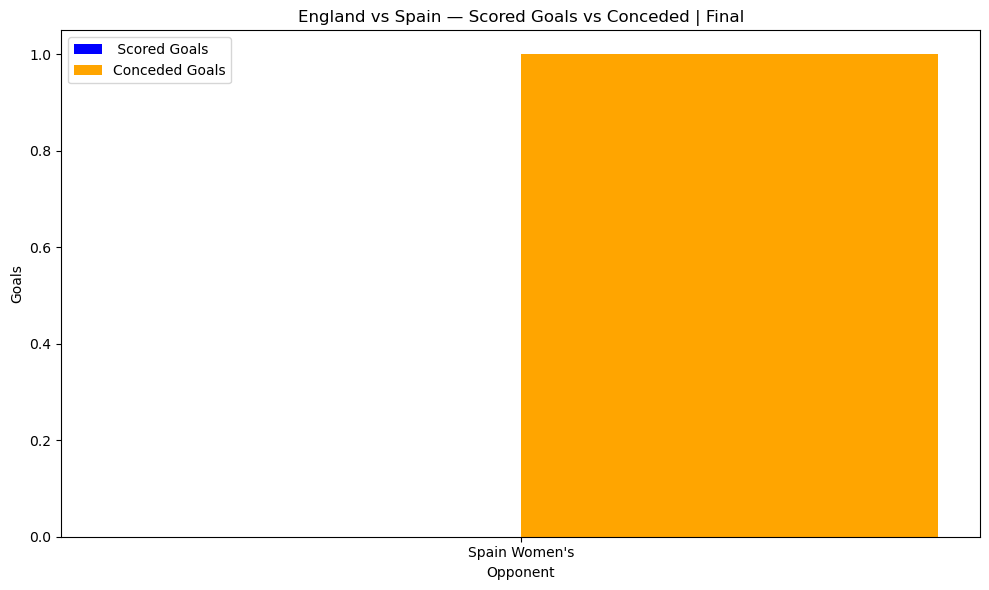

In [15]:
final = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "England Women's") &
    (womens_world_cup_stats["stage"] == "Final")
].copy()

final["match_date"] = pd.to_datetime(final["match_date"])

final = final.sort_values("match_date")

x = np.arange(len(final))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    final["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    final["goals_against"],
    width,
    label= "Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    final["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("England vs Spain — Scored Goals vs Conceded | Final")

plt.legend()

plt.tight_layout()
plt.show()

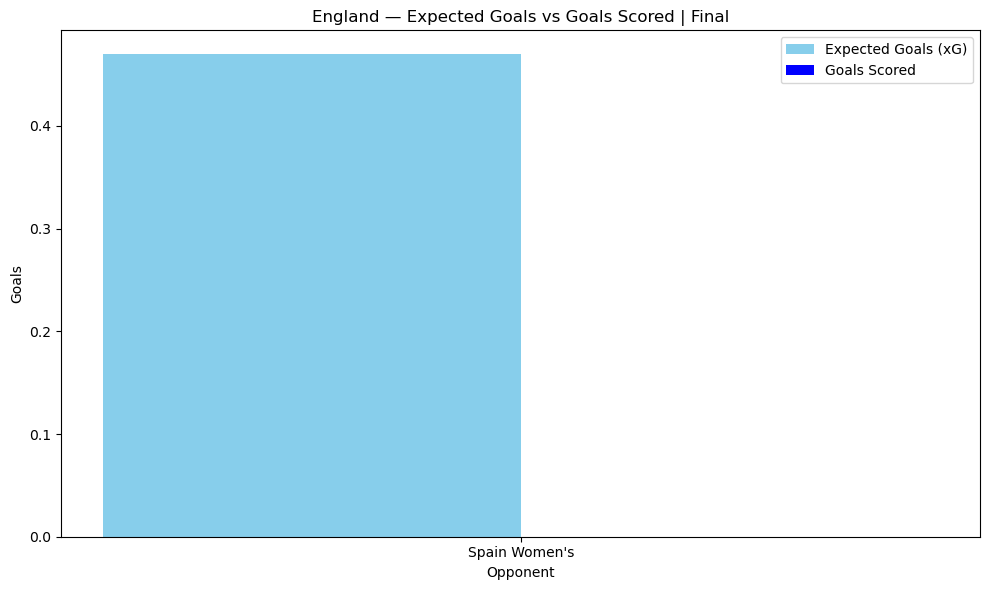

In [17]:
final = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "England Women's") &
    (womens_world_cup_stats["stage"] == "Final")
].copy()

final["match_date"] = pd.to_datetime(final["match_date"])

final = final.sort_values("match_date")

x = np.arange(len(final))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    final["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    final["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    final["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("England — Expected Goals vs Goals Scored | Final")

plt.legend()

plt.tight_layout()
plt.show()

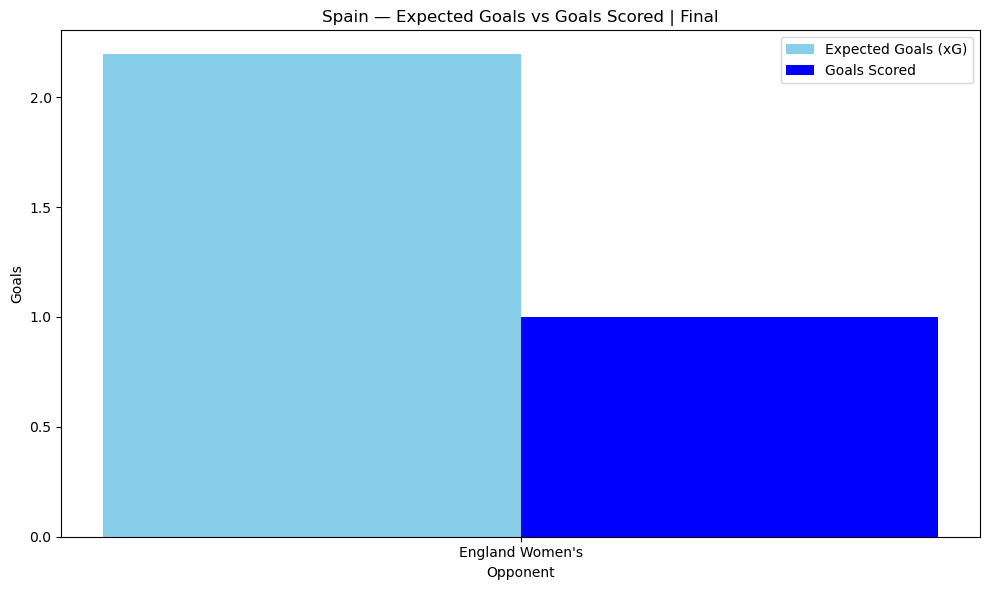

In [19]:
final = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Spain Women's") &
    (womens_world_cup_stats["stage"] == "Final")
].copy()

final["match_date"] = pd.to_datetime(final["match_date"])

final = final.sort_values("match_date")

x = np.arange(len(final))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    final["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    final["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    final["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Spain — Expected Goals vs Goals Scored | Final")

plt.legend()

plt.tight_layout()
plt.show()

In [25]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "England Women's") &
        (womens_world_cup_stats["opponent"] == "Spain Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Spain Women's") &
        (womens_world_cup_stats["opponent"] == "England Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries",
    "Goals from Shots": "goals_from_shots",
    "Own Goals From": "own_goals_for",	
    "Own Goals Against": "own_goals_against",	
    "Goal type": "goal_type"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "England": [
        match.loc[
            match["team"] == "England Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Spain": [
        match.loc[
            match["team"] == "Spain Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["England", "Spain"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["England", "Spain"]
].round(1)


# Display table

comparison

,Metric,England,Spain
0,Goals,0,1
1,xG,0.469679,2.194123
2,Goals Minus xG,-0.469679,-1.194123
3,Shots,8,14
4,Shots on Target,3,5
5,Saves,4,3
6,Possession %,44.284665,55.715335
7,Pass Accuracy %,71.813725,81.117534
8,Progressive Passes,99.0,104.0
9,Progressive Carries,19.0,21.0


Teams found:
["England Women's" "Spain Women's"]


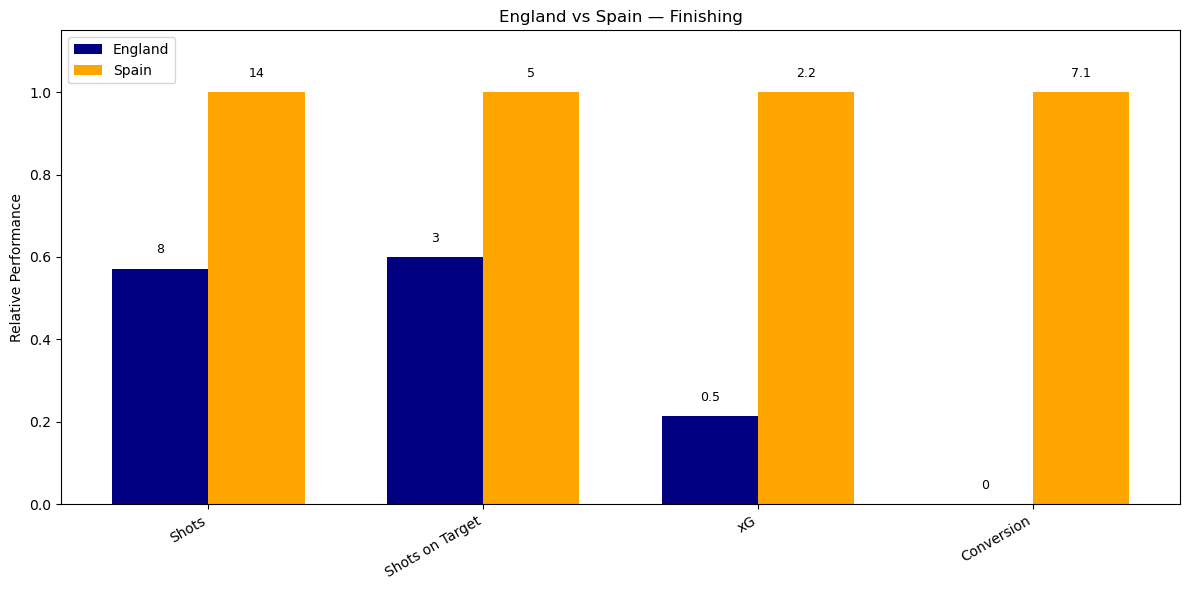

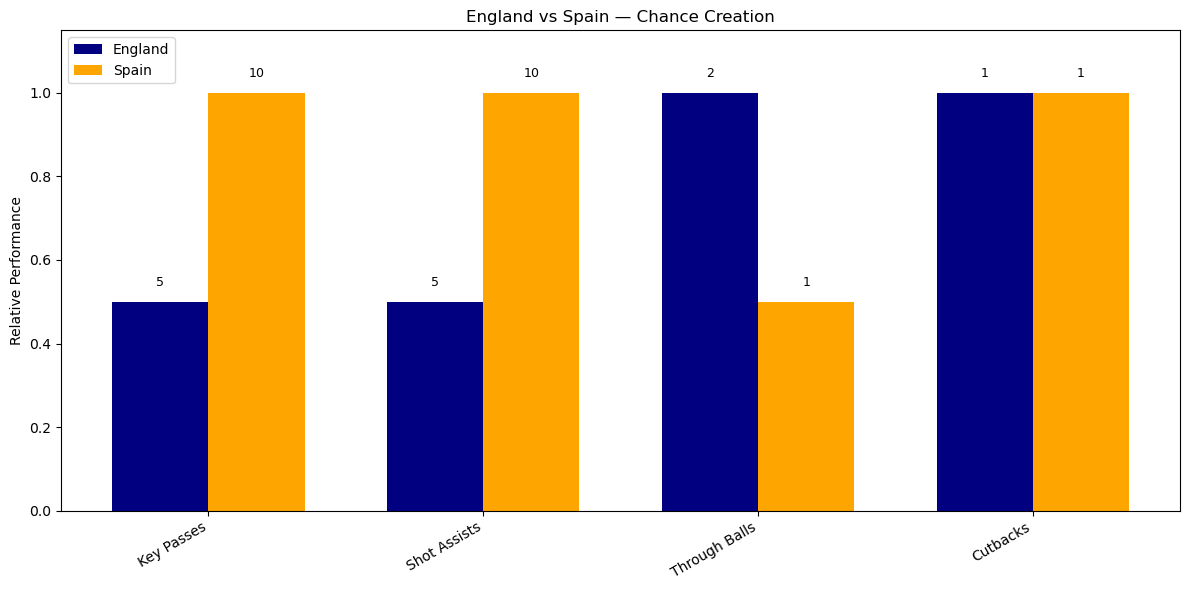

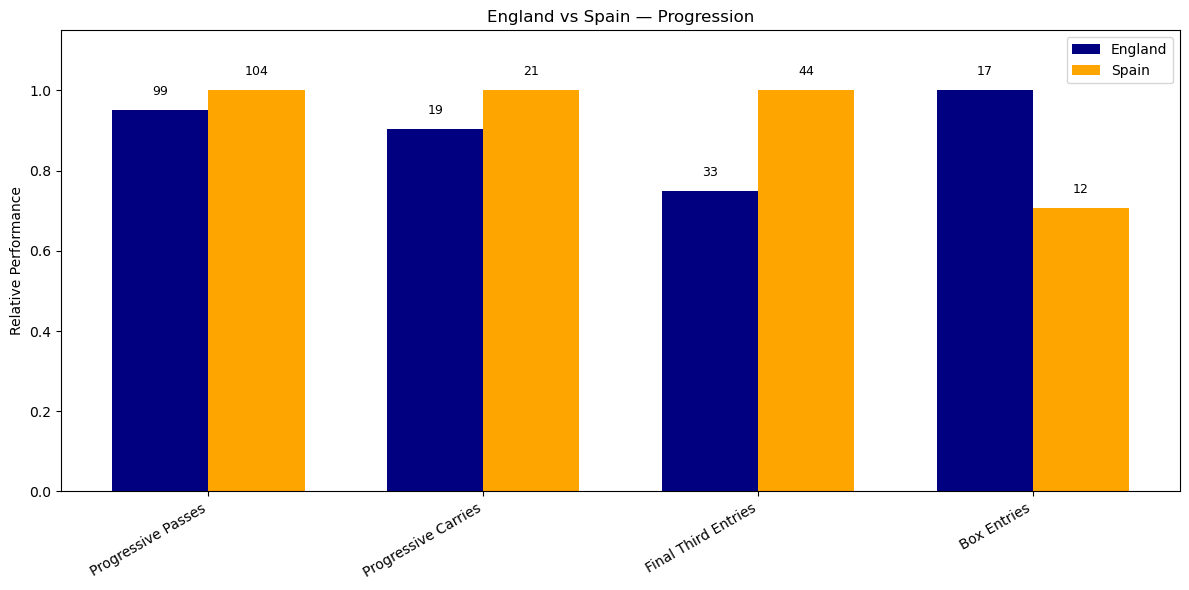

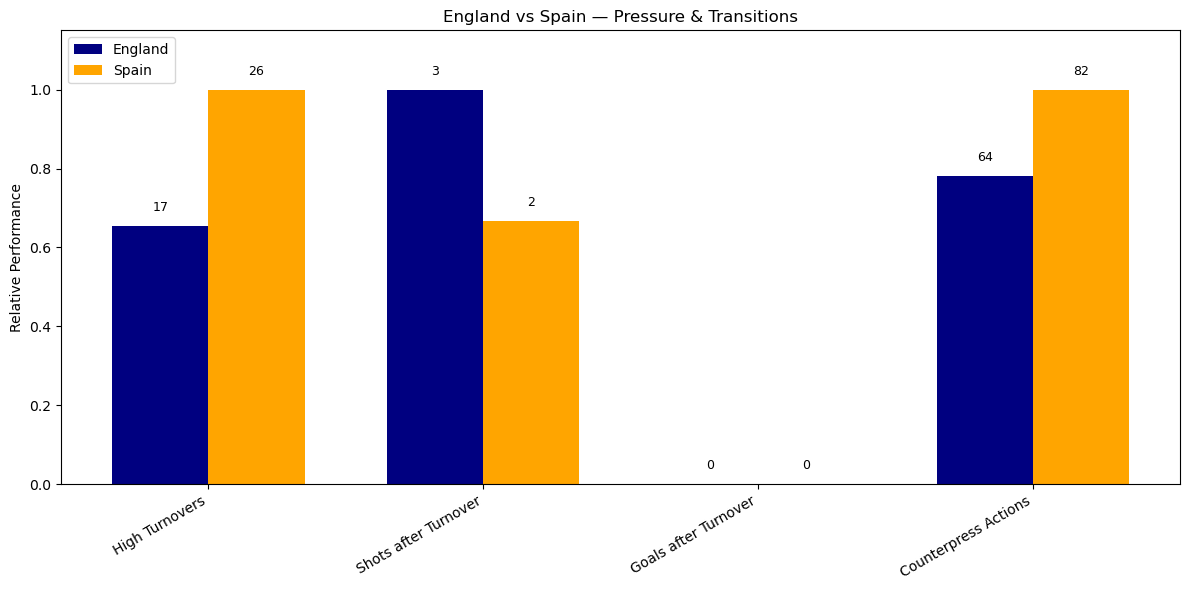

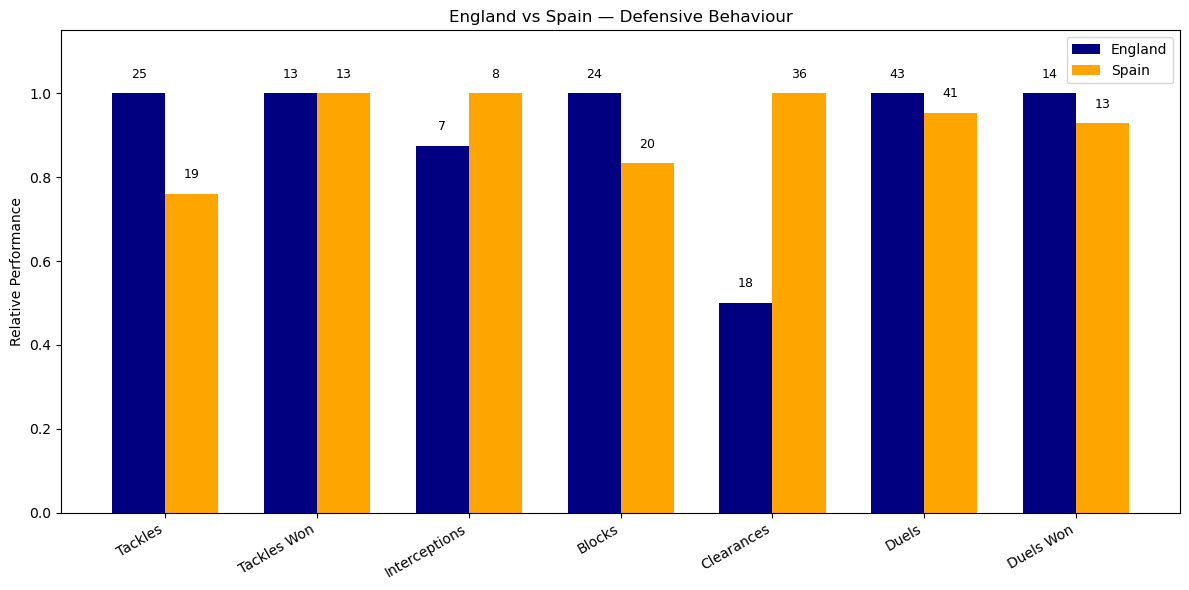

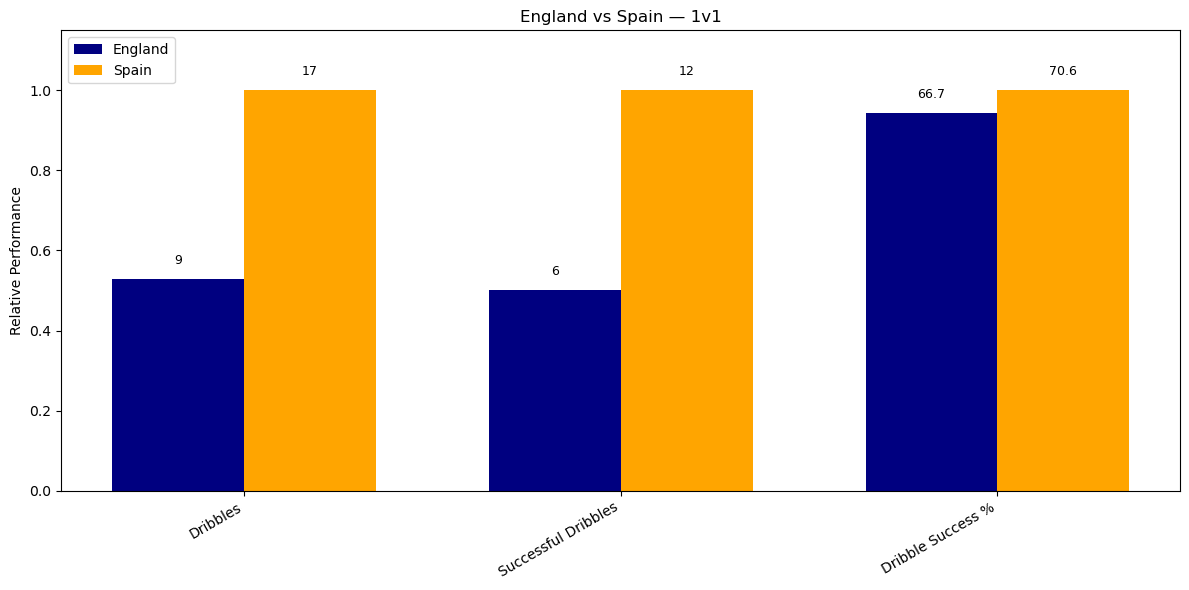

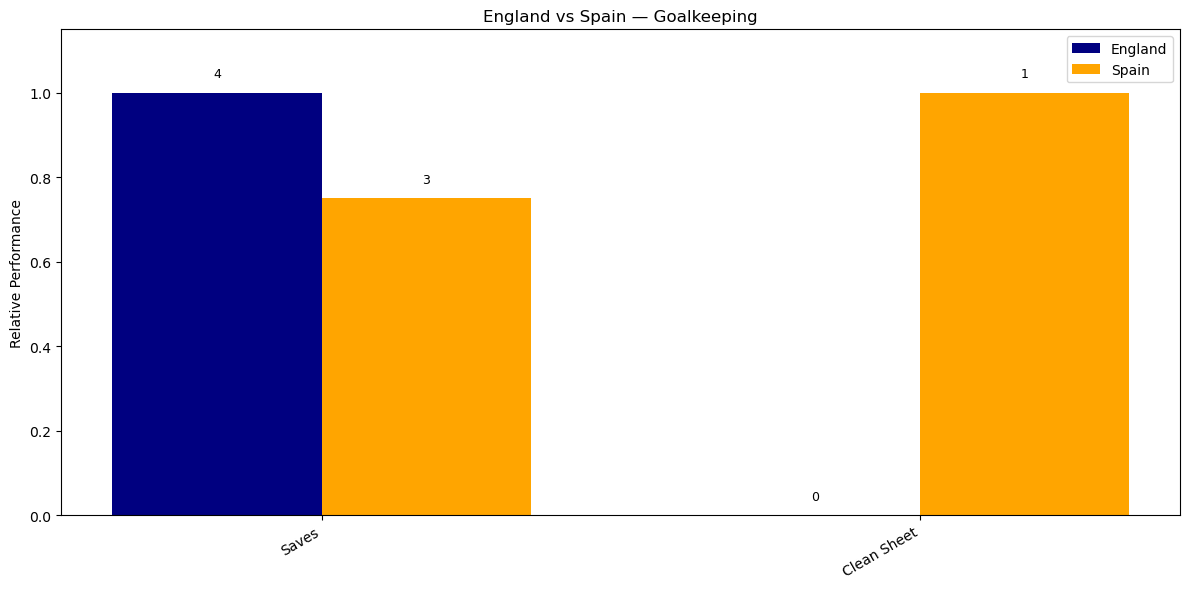

In [27]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (
            (womens_world_cup_stats["team"] == "England Women's") &
            (womens_world_cup_stats["opponent"] == "Spain Women's")
        )
        |
        (
            (womens_world_cup_stats["team"] == "Spain Women's") &
            (womens_world_cup_stats["opponent"] == "England Women's")
        )
    )
    &
    (womens_world_cup_stats["stage"] == "Final")
].copy()


# ============================================================
# 2. TEAM NAMES
# ============================================================

team_names = {
    "England": "England Women's",
    "Spain": "Spain Women's"
}


# ============================================================
# 3. METRICS BY CATEGORY
# ============================================================

categories = {


    "Finishing": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "xG": "xG",
        "Conversion": "conversion_pct"
    },


     "Chance Creation": {
        "Key Passes": "key_passes",
        "Shot Assists": "shot_assists",
        "Through Balls": "through_balls",
        "Cutbacks": "cutbacks"
    },



    "Progression": {
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries"
    },



    "Pressure & Transitions": {
        "High Turnovers": "high_turnovers",
        "Shots after Turnover": "shots_after_turnover",
        "Goals after Turnover": "goals_after_turnover",
        "Counterpress Actions": "counterpress_actions"
    },



    "Defensive Behaviour": {
        "Tackles": "tackles",
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Duels": "duels",
        "Duels Won": "duels_won"
    },



    "1v1": {
        "Dribbles": "dribbles",
        "Successful Dribbles": "successful_dribbles",
        "Dribble Success %": "dribble_success_pct"
    },



    "Goalkeeping": {
        "Saves": "saves",
        "Clean Sheet": "clean_sheet"
    }
}


# ============================================================
# 4. CHECK TEAMS
# ============================================================

print("Teams found:")
print(match["team"].unique())


# ============================================================
# 5. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # --------------------------------------------------------
    # Get real values
    # --------------------------------------------------------

    eng_values = np.array([
        match.loc[
            match["team"] == team_names["England"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    spa_values = np.array([
        match.loc[
            match["team"] == team_names["Spain"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)


    # --------------------------------------------------------
    # Maximum value for each metric
    # --------------------------------------------------------

    max_values = np.maximum(
        eng_values,
        spa_values
    )


    # --------------------------------------------------------
    # Normalize
    # --------------------------------------------------------

    eng_normalized = np.divide(
        eng_values,
        max_values,
        out=np.zeros_like(eng_values),
        where=max_values != 0
    )


    spa_normalized = np.divide(
        spa_values,
        max_values,
        out=np.zeros_like(spa_values),
        where=max_values != 0
    )


    # --------------------------------------------------------
    # Position of bars
    # --------------------------------------------------------

    x = np.arange(len(metrics))
    width = 0.35


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))


    bars_eng = plt.bar(
        x - width / 2,
        eng_normalized,
        width,
        label="England",
        color="navy"
    )


    bars_spa = plt.bar(
        x + width / 2,
        spa_normalized,
        width,
        label="Spain",
        color="orange"
    )


    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(
        bars_eng,
        eng_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    for bar, value in zip(
        bars_spa,
        spa_values
    ):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )


    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"England vs Spain — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [29]:
match[[
    "team",
    "opponent",
    "formation"
]]

,team,opponent,formation
126,England Women's,Spain Women's,3-4-1-2
127,Spain Women's,England Women's,4-2-3-1


In [31]:
formation_comparison = pd.DataFrame({
    "Metric": [
        "Formation",
        "Possession %",
        "Shots",
        "xG",
        "Progressive Passes",
        "Progressive Carries",
        "Final Third Entries",
        "Box Entries",
        "High Turnovers",
        "Interceptions",
        "Clearances"
    ],

    "England": [
        match.loc[
            match["team"] == "England Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "England Women's",
            "clearances"
        ].iloc[0]
    ],

    "Spain": [
        match.loc[
            match["team"] == "Spain Women's",
            "formation"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "possession_pct"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "shots"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "xG"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "progressive_passes"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "progressive_carries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "final_third_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "box_entries"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "high_turnovers"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "interceptions"
        ].iloc[0],
        
        match.loc[
            match["team"] == "Spain Women's",
            "clearances"
        ].iloc[0]
    ]
})

# Arredondar percentagens e xG
formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["England", "Spain"]
] = formation_comparison.loc[
    formation_comparison["Metric"].isin(
        ["Possession %", "xG"]
    ),
    ["England", "Spain"]
].round(1)

formation_comparison

,Metric,England,Spain
0,Formation,3-4-1-2,4-2-3-1
1,Possession %,44.284665,55.715335
2,Shots,8,14
3,xG,0.469679,2.194123
4,Progressive Passes,99.0,104.0
5,Progressive Carries,19.0,21.0
6,Final Third Entries,33.0,44.0
7,Box Entries,17.0,12.0
8,High Turnovers,17.0,26.0
9,Interceptions,7,8


## Conclusion ENG-SPA

The final brought together two of the strongest teams in the tournament, and Spain clearly dominated the attacking and possession metrics. They recorded more possession, shots, xG, final-third entries and high turnovers, while England struggled to create high-quality chances. Both teams finished below their xG, highlighting limitations in finishing, although Spain ultimately converted one of their opportunities to win the match.

Spain also showed greater passing accuracy and attacking pressure, while England's 3-4-1-2 provided more defensive presence but fewer attacking opportunities. The 4-2-3-1 allowed Spain to maintain a stronger attacking structure and greater control of the game. Overall, the metrics support Spain's victory, with a more consistent performance across possession, progression, chance creation and pressure, ultimately making them deserving World Cup champions.